In this notebook, we make the paper plots regarding the fastspec catalog!!

In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import matplotlib.ticker as mticker
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import glob
from matplotlib.lines import Line2D

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, process_img
from desi_lowz_funcs import calc_normalized_dist, sdss_rgb, get_scrollable_pdfs
from desi_lowz_funcs import find_objects_nearby, print_radecs
# from construct_dwarf_galaxy_catalogs import process_sga_matches

import warnings
from astropy.wcs import FITSFixedWarning

from desi_lowz_funcs import plot_2d_dist


# Suppress just FITSFixedWarning
warnings.filterwarnings('ignore', category=FITSFixedWarning)


%load_ext autoreload
%autoreload 2

# python3 desi_dwarfs/code/dwarf_photo_pipeline.py -sample SGA -min 0 -max 100000 -run_parr -ncores 1 -overwrite -nchunks 1 -no_cnn_cut -use_sample sga -run_aper -run_cog -tgids 39628500637844206



In [2]:
import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar
    

In [3]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }


In [12]:
# from consolidate_photometry import get_fastspec_fit_catalog
# get_fastspec_fit_catalog()

In [5]:
# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main = Table.read(filename, hdu="MAIN")

# Option 2: load the SPEC_DERIVED extension (dwarf catalog)
fastspec = Table.read(filename, hdu="SPEC_DERIVED")


Plot 1) Comparing the nebular diagnostics of dwarfs in different samples ELG, BGS_BRIGHT for example

In [137]:
from fastspec_funcs import line_snr_mask, compute_o32, compute_r32
from catalog_paper_plots import make_cmap

ImportError: cannot import name 'line_snr_mask' from 'fastspec_funcs' (/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/fastspec_funcs.py)

In [6]:
photo_mask = (main["DWARF_MASKBIT"] == 0) & (main["LOG_MSTAR_M24"] < 9)

#get the snr > 3 mask
snr_mask = line_snr_mask(fastspec, line_names=["HBETA","HALPHA","OIII_5007", "OIII_4959","OII_3726"],snr_val=3)


In [7]:
fspec_cat = fastspec[photo_mask & snr_mask]
main_cat = main[photo_mask & snr_mask]


In [8]:
dwarf_o32 = compute_o32(fspec_cat)
dwarf_r32 = compute_r32(fspec_cat)


In [9]:
len(dwarf_o32)

129199

In [10]:
# === For q = 3e8 ===
oh_q3e8 = np.array([
    7.627891156462585,
    7.9326530612244905,
    8.231972789115646,
    8.631972789115647,
    8.931292517006803,
    9.10544217687075,
    9.233333333333334,
    9.407482993197279,
])

# === For q = 8e7 ===
oh_q8e7 = np.array([
    7.630612244897959,
    7.9326530612244905,
    8.23469387755102,
    8.631972789115647,
    8.931292517006803,
    9.108163265306123,
    9.233333333333334,
    9.404761904761905,
])

oh_list = 0.5*(oh_q3e8 + oh_q8e7)

In [11]:
# ## get the kewley and dopita photoionization tracks

# #for q = 3e8

# #12+[o/h], r32
# 7.627891156462585, 0.6521764534034471
# 7.9326530612244905, 0.851614081215308
# 8.231972789115646, 0.9651475314051999
# 8.631972789115647, 0.8803315804849544
# 8.931292517006803, 0.4999999999999998
# 9.10544217687075, -0.09539146947122479
# 9.233333333333334, -0.5352322524101671
# 9.407482993197279, -1.5654396728016367
# #q, o32

# 8.479108635097493, 1.417085427135678
# 8.479108635097493, 1.2763819095477387
# 8.479108635097493, 1.0686767169179228
# 8.481894150417826, 0.793969849246231
# 8.481894150417826, 0.45226130653266305
# 8.479108635097493, 0.010050251256281229
# 8.481894150417826, -0.4857621440536013
# 8.47632311977716, -1.2696817420435513


# #for q = 8e7

# #12+[o/h], r32
# 7.630612244897959, 0.4857727139935728
# 7.9326530612244905, 0.7227797253870872
# 8.23469387755102, 0.8846333625474727
# 8.631972789115647, 0.8803315804849544
# 8.931292517006803, 0.6019938650306746
# 9.108163265306123, 0.1622845457201283
# 9.233333333333334, -0.2882997370727436
# 9.404761904761905, -1.409772129710781

# #q, o32
# 7.902506963788301, 0.7135678391959797
# 7.902506963788301, 0.5862646566164151
# 7.902506963788301, 0.41876046901172503
# 7.905292479108635, 0.19095477386934667
# 7.902506963788301, -0.07035175879397038
# 7.902506963788301, -0.22445561139028491
# 7.902506963788301, -0.512562814070352
# 7.905292479108635, -1.0083752093802345


r32_q3e8 = [0.6522, 0.8516, 0.9651, 0.8803, 0.5000, -0.0954, -0.5352, -1.5654]
o32_q3e8 = [1.4171, 1.2764, 1.0687, 0.7940, 0.4523, 0.0101, -0.4858, -1.2697]

r32_q8e7 = [0.4858, 0.7228, 0.8846, 0.8803, 0.6020, 0.1623, -0.2883, -1.4098]
o32_q8e7 = [0.7136, 0.5863, 0.4188, 0.1910, -0.0704, -0.2245, -0.5126, -1.0084]

print(len(oh_list), len(r32_q3e8))

#let us get smooth functional forms for this
from scipy.interpolate import UnivariateSpline 

def x_to_y(x, y, xlab, ylab):

    x = np.array(x)
    y = np.array(y)

    sort_inds = np.argsort(x)
    
    spl = UnivariateSpline(x[sort_inds], y[sort_inds],s=0.01)

    # Evaluate on a fine grid
    xfit = np.linspace(-1.5, 2, 300)
    
    # Plot data and fits
    plt.figure(figsize=(3, 3))
    # plt.scatter(o32_q8e7, r32_q8e7, label="data", color="k", s=30)
    plt.scatter(x, y, label="data", color="k", s=30)
    
    plt.plot(xfit, spl(xfit), label="spline", color="darkorange", lw=2)
    
    plt.xlim([-1.5,2])
    plt.ylim([-1.5,1])
    
    plt.xlabel(f"{xlab}")
    plt.ylabel(f"{ylab}")
    plt.legend()
    plt.show()

    return spl


def oh_to_r23(oh_list, r32):
    spl = UnivariateSpline(oh_list, r32,s=0.0)

    # Evaluate on a fine grid
    xfit = np.linspace(7.4, 9.5, 100)
    
    # Plot data and fits
    plt.figure(figsize=(3, 3))
    plt.scatter(oh_list, r32, label="data", color="k", s=30)
    
    plt.plot(xfit, spl(xfit), label="spline", color="darkorange", lw=2)
    
    plt.xlim([7.5,9.6])
    plt.ylim([-1.5,1.5])
    
    plt.xlabel("12+O/H")
    plt.ylabel("R32")
    plt.legend()
    plt.show()

    return spl




8 8


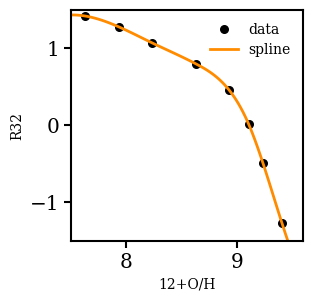

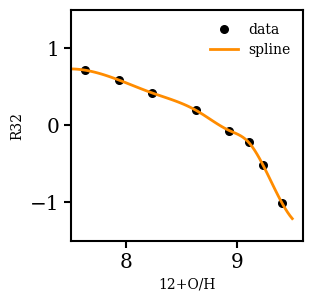

In [12]:
spl_oh_to_o32_3e8 = oh_to_r23(oh_list, o32_q3e8)
spl_oh_to_o32_8e7 = oh_to_r23(oh_list, o32_q8e7)


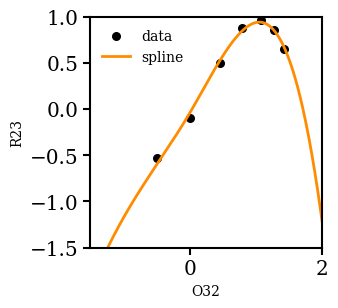

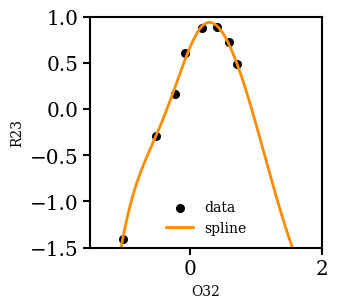

In [13]:
spl_o32_to_r23_3e8 = x_to_y(o32_q3e8, r32_q3e8, xlab="O32",ylab="R23")
spl_o32_to_r23_8e7 = x_to_y(o32_q8e7, r32_q8e7, xlab="O32",ylab="R23")

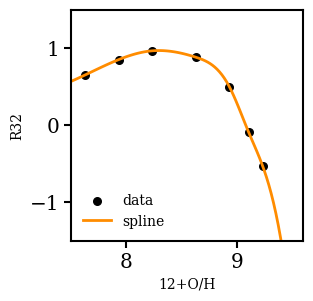

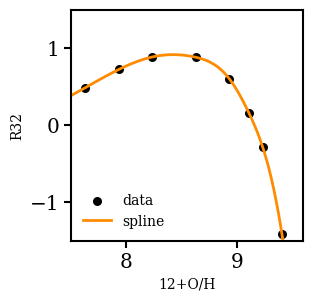

In [14]:
spl_oh_to_r23_3e8 = oh_to_r23(oh_list, r32_q3e8)
spl_oh_to_r23_8e7 = oh_to_r23(oh_list, r32_q8e7)


In [19]:
def get_bgsb_massive_stuff(hpx):
    #opening some random fastspec file that has a lot of 
    fspec_hdu = fits.open(f"/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/catalogs/fastspec-iron-main-bright-nside1-hp{hpx}.fits")

    print("Done reading file!")
    metadata = fspec_hdu["METADATA"].data
    specphot = fspec_hdu["SPECPHOT"].data
    fastspec_all = fspec_hdu["FASTSPEC"].data

    zmask = (metadata["DELTACHI2"] > 40) & (metadata["SPECTYPE"] == "GALAXY")
    mstar_mask = (specphot["LOGMSTAR"] > 10)
    tot_mask = zmask & mstar_mask

    fastspec_non_dwarf = Table(fastspec_all[tot_mask])

    print("Obtained filtered fastspec table!")

    
    snr_non_dwarf_mask = line_snr_mask(fastspec_non_dwarf, line_names=["HBETA","HALPHA","OIII_5007", "OIII_4959","OII_3726"],snr_val=3)

    all_o32 = compute_o32(fastspec_non_dwarf[snr_non_dwarf_mask])
    all_r32 = compute_r32(fastspec_non_dwarf[snr_non_dwarf_mask])

    return all_r32, all_o32


all_r32_1, all_o32_1 = get_bgsb_massive_stuff("01")
all_r32_2, all_o32_2 = get_bgsb_massive_stuff("06")

#let us stack these
all_r32 = np.concatenate([all_r32_1, all_r32_2])
all_o32 = np.concatenate([all_o32_1, all_o32_2])



Done reading file!
Obtained filtered fastspec table!
Done reading file!
Obtained filtered fastspec table!


In [20]:
# fig,ax = make_subplots(ncol = 1, nrow = 1, return_fig=True)

# # ax[0].scatter(np.log10(dwarf_r32), np.log10(dwarf_o32),s=1,alpha=0.1,color = "darkcyan")
# # ax[0].scatter(np.log10(all_r32), np.log10(all_o32),s=1,alpha=0.05,color = "grey")

# plot_2d_dist(np.log10(all_r32), np.log10(all_o32), 100, 100, 
#                 cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68,0.95],ax=ax[0], bounds= np.log10(np.array([ 0.5,20,0.1,100 ])),
#             cmap = make_cmap("k"), color = "grey", filled=True, label = "BGS Bright",cmap_alpha=1)

# plot_2d_dist(np.log10(dwarf_r32), np.log10(dwarf_o32), 250, 250, 
#                 cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68,0.95,0.997],ax=ax[0], bounds= np.log10(np.array([ 0.5,20,0.1,100 ])),
#             cmap = make_cmap("darkcyan"), color = "k", filled=True, label = "BGS Bright",cmap_alpha=1)


# for axi in ax:
#     axi.set_xlim(np.log10(np.array([0.5,20])))
    
#     axi.set_ylim(np.log10(np.array([0.1,100])))
    
#     major_xticks = np.array([1, 10])
#     major_yticks = np.array([0.1, 1, 10,100])
#     axi.set_xticks(np.log10(major_xticks))
#     axi.set_yticks(np.log10(major_yticks))
#     axi.set_xticklabels(major_xticks, fontsize=14)
#     axi.set_yticklabels(major_yticks, fontsize=14)
    
#     # --- Minor ticks (equally spaced in linear space, then log10) ---
#     minor_xticks = np.log10(np.array([2,3,4,5,6,7,8,9,20]))  # between 1 and 10
#     minor_yticks = np.log10(np.array([0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,2,3,4,5,6,7,8,9,20,30,40,50,60,70,80,90]))  # between 0.1-1 and 1-10
#     axi.set_xticks(minor_xticks, minor=True)
#     axi.set_yticks(minor_yticks, minor=True)
    
#     axi.tick_params(which='major', length=8)
#     axi.tick_params(which='minor', length=4)

# ax[0].set_ylabel(r'[OIII]$_{\mathregular{5007}}$ / [OII]$_{\mathregular{3727}}$', fontsize=15)
# ax[0].set_xlabel(r'[OIII]$_{\mathregular{5007}}$ + [OII]$_{\mathregular{3727}}$ / H$\beta$', fontsize=15)
    
# # ax[0].text(0.3,0.75,"DESI DR1\n $z < 0.5$",fontsize = 15,color = "k",transform=ax[0].transAxes, ha='center',  va='bottom')

# ax[0].text(0.05,0.9,r"DESI Dwarfs, $M_{\bigstar} < 10^{9} M_{\odot}$",fontsize = 12,color = "darkcyan",
#            transform=ax[0].transAxes, weight="bold")

# ax[0].text(0.05,0.8,r"DESI, $M_{\bigstar} > 10^{10} M_{\odot}$",fontsize = 12,color = "grey",
#            transform=ax[0].transAxes,weight="bold")

# plt.show()

In [21]:
from matplotlib.ticker import StrMethodFormatter

/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1611: RuntimeWarning: divide by zero encountered in true_divide
  res *= (1 - noise / lVar)
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1611: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2040: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contourf(X, Y, H, linewidths=np.array([1.0,0.75, 0.5, 0.25])[::-1], cmap=cmap, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2040: UserWarning: linewidths is ignored by contourf
  cs = ax.contourf(X, Y, H, linewidths=np.array([1.0,0.75, 0.5, 0.25])[::-1], cmap=cmap, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2040: UserWarning

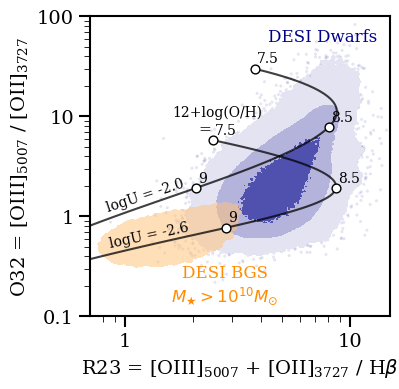

In [80]:
fig,ax = make_subplots(ncol = 1, nrow = 1, return_fig=True)
# fig,ax = plt.subplots(1,1,figsize = (5,5))
# ax = [ax]

ax[0].scatter(np.log10(dwarf_r32), np.log10(dwarf_o32),s=5,alpha=0.1,facecolor = "darkblue",edgecolor="none", rasterized=True)

plot_2d_dist(np.log10(dwarf_r32), np.log10(dwarf_o32), 250, 250, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68,0.95,0.997],ax=ax[0], bounds= np.log10(np.array([ 0.4,20,0.1,100 ])),
            cmap = make_cmap("darkblue"), color = "k", filled=True, label = "BGS Bright",cmap_alpha=1)

plot_2d_dist(np.log10(all_r32), np.log10(all_o32), 100, 100, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68],ax=ax[0], bounds= np.log10(np.array([ 0.4,20,0.1,100 ])),
            cmap = make_cmap("darkorange"), color = "grey", filled=True, label = "BGS Bright",cmap_alpha=0.55)

# plot_2d_dist(np.log10(all_r32), np.log10(all_o32), 100, 100, 
#                 cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68,0.95],ax=ax[0], bounds= np.log10(np.array([ 0.4,20,0.1,100 ])),
#             cmap = make_cmap("k"), color = "grey", filled=False, label = "BGS Bright",cmap_alpha=0.5)


for axi in ax:
    axi.set_xlim(np.log10(np.array([0.7,15])))
    
    axi.set_ylim(np.log10(np.array([0.1,100])))
    
    major_xticks = np.array([1, 10])
    major_yticks = np.array([0.1, 1, 10,100])
    axi.set_xticks(np.log10(major_xticks))
    axi.set_yticks(np.log10(major_yticks))
    axi.set_xticklabels(major_xticks, fontsize=14)
    axi.set_yticklabels(major_yticks, fontsize=14)
    axi.set_yticklabels([f"{int(y)}" if y >= 1 else f"{y:g}" for y in major_yticks], fontsize=14)

    # --- Minor ticks (equally spaced in linear space, then log10) ---
    minor_xticks = np.log10(np.array([0.8,0.9,2,3,4,5,6,7,8,9]))  # between 1 and 10
    minor_yticks = np.log10(np.array([0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,2,3,4,5,6,7,8,9,20,30,40,50,60,70,80,90]))  # between 0.1-1 and 1-10
    axi.set_xticks(minor_xticks, minor=True)
    axi.set_yticks(minor_yticks, minor=True)
    
    axi.tick_params(which='major', length=8)
    axi.tick_params(which='minor', length=4)

ax[0].set_ylabel(r'O32 = [OIII]$_{\mathregular{5007}}$ / [OII]$_{\mathregular{3727}}$', fontsize=14)
ax[0].set_xlabel(r'R23 = [OIII]$_{\mathregular{5007}}$ + [OII]$_{\mathregular{3727}}$ / H$\beta$', fontsize=14)
    
# ax[0].text(0.3,0.75,"DESI DR1\n $z < 0.5$",fontsize = 15,color = "k",transform=ax[0].transAxes, ha='center',  va='bottom')

ax[0].text(0.775,0.915,r"DESI Dwarfs",fontsize = 12,color = "darkblue",
           transform=ax[0].transAxes,ha="center")

ax[0].text(0.45,0.05,r"DESI BGS" + "\n" + r"$M_{\bigstar} > 10^{10} M_{\odot}$",fontsize = 12,color = "darkorange",
           transform=ax[0].transAxes,ha="center")

o32_3e8_grid = np.linspace( np.min(o32_q3e8) , np.max(o32_q3e8)+0.06, 100 )

#plot the photo-ionization tracks
ax[0].plot(spl_o32_to_r23_3e8(o32_3e8_grid), o32_3e8_grid, 'k', ls = "-",alpha=0.75, zorder = 10)

for oh in [7.5,8.5,9]:
    x_curve = spl_o32_to_r23_3e8(o32_3e8_grid)
    y_curve = o32_3e8_grid
    
    # Original approximate point
    x_target = spl_oh_to_r23_3e8(oh)
    y_target = spl_oh_to_o32_3e8(oh)

    # Compute Euclidean distance to every point on the curve
    distances = np.sqrt((x_curve - x_target)**2 + (y_curve - y_target)**2)

    # Find the index of the closest curve point
    idx_closest = np.argmin(distances)
    x_closest = x_curve[idx_closest]
    y_closest = y_curve[idx_closest]

    # Plot it
    ax[0].scatter(x_closest, y_closest, facecolor="white", edgecolor="k", s=40, zorder = 20)
    ax[0].text(x_closest + 0.01, y_closest + 0.06, f"{oh}", color = "k", fontsize = 10)

    
#let us draw dots at the specific metallicity points

o32_8e7_grid = np.linspace( np.min(o32_q8e7) , np.max(o32_q8e7)+0.05, 100 )

ax[0].plot(spl_o32_to_r23_8e7(o32_8e7_grid), o32_8e7_grid, 'k', ls = "-",alpha=0.75,zorder=10)

for oh in [7.5,8.5,9]:
    x_curve = spl_o32_to_r23_8e7(o32_8e7_grid)
    y_curve = o32_8e7_grid
    
    # Original approximate point
    x_target = spl_oh_to_r23_8e7(oh)
    y_target = spl_oh_to_o32_8e7(oh)

    # Compute Euclidean distance to every point on the curve
    distances = np.sqrt((x_curve - x_target)**2 + (y_curve - y_target)**2)

    # Find the index of the closest curve point
    idx_closest = np.argmin(distances)
    x_closest = x_curve[idx_closest]
    y_closest = y_curve[idx_closest]

    # Plot it
    ax[0].scatter(x_closest, y_closest, facecolor="white", edgecolor="k", s=40, zorder = 20)
    ax[0].text(x_closest + 0.01, y_closest + 0.06, f"{oh}", color = "k", fontsize = 10)


ax[0].text(0.21,1,"12+log(O/H)",fontsize = 10,color = "k")
ax[0].text(0.325,0.825,"=",fontsize = 11,color = "k")

c_cms = 3e5*1e3*1e2

ax[0].text(0.05,0.35,f"logU = {np.log10(3e8/c_cms):.1f}", fontsize = 10,color="k", transform=ax[0].transAxes,rotation=18)

ax[0].text(0.06,0.23,f"logU = {np.log10(8e7/c_cms):.1f}", fontsize = 10,color="k", transform=ax[0].transAxes,rotation=12)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_nebular_diag.pdf",bbox_inches="tight")

plt.show()

In [439]:
# # fspec_all = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_fastspec_catalog/iron_fastspec_v3.fits")
# snr_all_mask = line_snr_mask(fspec_all, line_names=["HBETA","HALPHA","OIII_5007", "OIII_4959","OII_3726"],snr_val=3)
# fspec_all = fspec_all[snr_all_mask]
# # fspec_non_dwarf = fspec_all[~np.isin(fspec_all["TARGETID"], fspec_cat["TARGETID"].data)]
# all_o32 = compute_o32(fspec_non_dwarf)
# all_r32 = compute_r32(fspec_non_dwarf)


## Multi-corner plot showing some more properties:


Halpha EW (no SNR cut), Mstar, g-r, r_eff, mu_r


In [11]:
from fastspec_funcs import get_halpha_sfrs

In [5]:
len(main)

410604

In [6]:
main_100mpc = main[(main["LUMI_DIST_MPC"] < 200) & (main["DWARF_MASKBIT"] == 0)]
fspec_100mpc = fastspec[(main["LUMI_DIST_MPC"] < 200) & (main["DWARF_MASKBIT"] == 0)]

In [7]:
main_100mpc["g-r"] = main_100mpc["MAG_G"] - main_100mpc["MAG_R"] 

In [8]:
# main_100mpc = main_100mpc[ (fspec_100mpc["HALPHA_EW"] >=  0) ]
# fspec_100mpc = fspec_100mpc[ (fspec_100mpc["HALPHA_EW"] >=  0) ]


In [9]:
halpha_ew_100mpc = np.array(fspec_100mpc["HALPHA_EW"])
gr_100mpc = np.array(main_100mpc["g-r"] )
log_mstar = np.array(main_100mpc["LOG_MSTAR_M24"] )

print(len(halpha_ew_100mpc), len(gr_100mpc), len(log_mstar))

80893 80893 80893


In [12]:
##estimate the SFR using the total magnitude, the aperture correction will not be robust here, but interesting to plot
log_halpha_sfrs = get_halpha_sfrs(main_100mpc, fspec_100mpc["HALPHA_EW"], fspec_100mpc["HALPHA_EW_IVAR"])

/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/fastspec_funcs.py:65: RuntimeWarning: invalid value encountered in log10
  log_Ha_SFR = np.log10(SFR)


In [14]:
r12_arcsec = main_100mpc["SHAPE_PARAMS"].data[:,0]

mur_100mpc = main_100mpc["MAG_R"] + 2.5*np.log10(2*np.pi*r12_arcsec**2)

#update this using the Z_CMB instead of heliocentric redshift
r12_kpc = (Planck18.angular_diameter_distance( main_100mpc["Z_CMB"] ).value) * 1000 * r12_arcsec/206265


In [15]:
# mur[main_100mpc["PHOTOMETRY_UPDATED"]==1]

In [16]:
from astropy.cosmology import Planck18, z_at_value

In [17]:
r12_kpc.max()

0.8901287652938233

In [18]:
import cmasher as cmr

/tmp/ipykernel_1903390/1486551227.py:3: RuntimeWarning: invalid value encountered in log10
  data = [log_mstar, np.log10(halpha_ew_100mpc+1), log_halpha_sfrs,  gr_100mpc, np.log10(r12_kpc), mur_100mpc ]


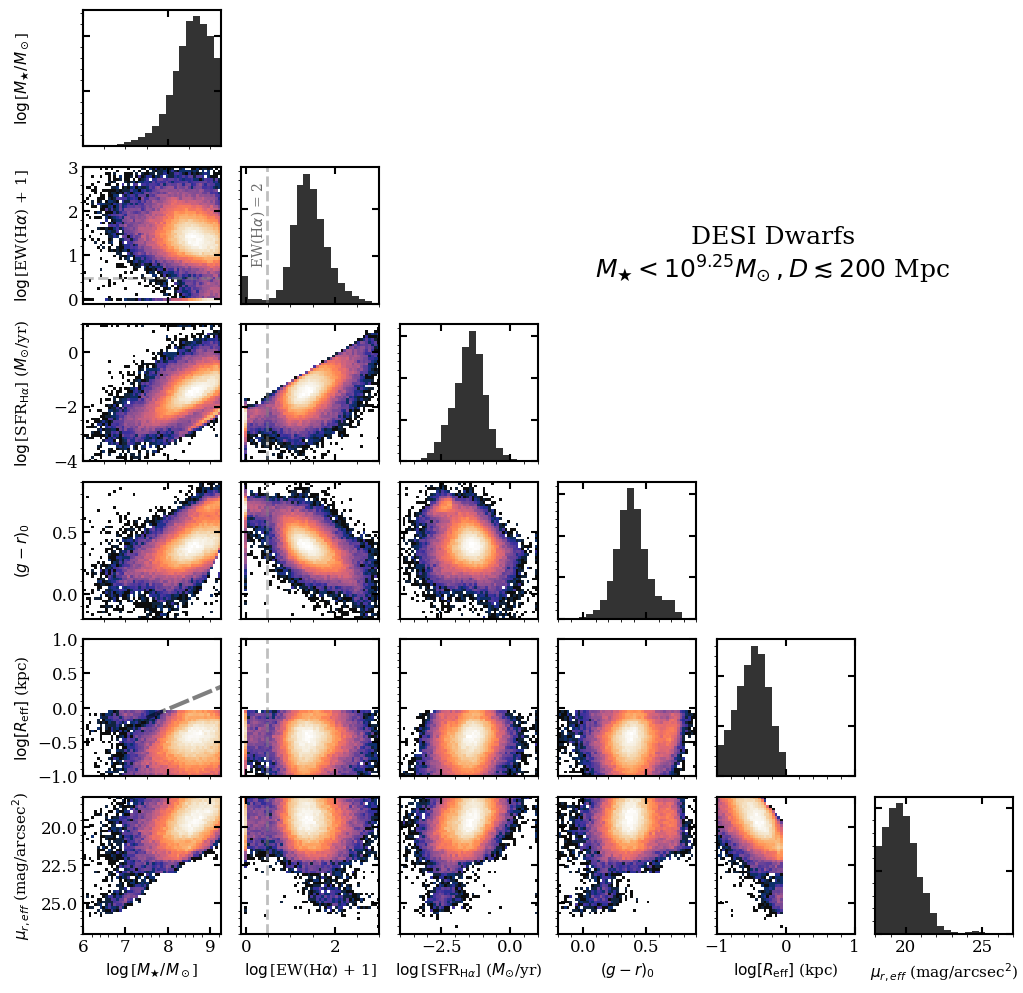

In [19]:

# === Data and labels ===
labels = [r"$\log$[$M_\bigstar / M_\odot$]", r"$\log$[EW(H$\alpha$) + 1]", r"$\log$[SFR$_{\text{H}\alpha}$] ($M_{\odot}$/yr)", r"$(g − r)_0$",r"$\log[R_{\rm eff}]$ (kpc)", r"$\mu_{r, eff}$ (mag/arcsec$^2$)"]
data = [log_mstar, np.log10(halpha_ew_100mpc+1), log_halpha_sfrs,  gr_100mpc, np.log10(r12_kpc), mur_100mpc ]
n = len(data)

# === User-specified limits (set None for auto) ===
limits = [
    (6, 9.25) ,        # for log(M*)
    (-0.1, 3),          # for log Hα EW + 1[Å]
    (-4, 1),          # for log sfr
    (-0.2, 0.9),      # for g−r
    (-1, 1),      # for reff
    (18, 27)       # for mur
]

# === Figure setup ===
fig, axes = plt.subplots(n, n, figsize=(12, 12))
plt.subplots_adjust(wspace=0.15, hspace=0.15)

fsize_label = 11

cmap = cmr.torch

# === Plot ===
for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i < j:
            ax.axis("off")
            continue

        if i == j:
            # 1D histogram on the diagonal
            ax.hist(
                data[i],
                bins=20,
                color="k",
                histtype="stepfilled",
                alpha=0.8,
                range=limits[i],
                rasterized=True
            )
            ax.set_xlim(limits[i])
            ax.set_yticklabels([])

        else:
            # 2D histogram (log-normalized for better dynamic range)
            h = ax.hist2d(
                data[j],
                data[i],
                bins=50,
                cmap=cmap,
                norm=LogNorm(),
                alpha=0.95,
                range=[limits[j], limits[i]],
                rasterized=True
            )

            
            ax.set_xlim(limits[j])

            if i == n-1:
                ax.set_ylim(limits[i][::-1])

        # Axis labels
        if i == n - 1:
            ax.set_xlabel(labels[j], fontsize=fsize_label)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(labels[i], fontsize=fsize_label)
        else:
            ax.set_yticklabels([])

        if j == 1:
            #we want to draw a line at EW = 2A, but we need to draw it at 6 as we are adding 1 to everything
            ax.axvline(x = np.log10(3),color = "grey",ls="--",lw=2,alpha=0.5 )      
            if i == j:
                ax.text(0.06,0.3,r"EW(H$\alpha$) = 2",color = "dimgrey",rotation=90,fontsize = 10,transform=ax.transAxes )

        if i == 1 and j == 0:
            ax.axhline(y = np.log10(3),color = "grey",ls="--",lw=2,alpha=0.5 )

        if j == 0 and i == n-1:
            ax.set_xticks([6,7,8,9])

        if j == 0 and i == n - 2:
            #plot the line from the SAGA size-mass paper
            mstar_grid = np.linspace(7.5,9.5)
            log_r12_model = 0.26*mstar_grid - 2.10
            ax.plot(mstar_grid, log_r12_model, color = "k",lw=3,zorder=10,alpha=0.5,ls=(0,(5,1)))
            
        # Tick and spine styling
        ax.tick_params(axis="both", labelsize=12, direction="in", top=True, right=True)
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.minorticks_on()

fig.text(
    0.7, 0.7,                              # x, y position (in figure coordinates)
    "DESI Dwarfs\n" r"$M_{\bigstar} < 10^{9.25} M_{\odot} \,, D \lesssim 200$ Mpc",   # text
    fontsize=18,
    ha="center", va="top", color="k"
)


# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_corner_plot.pdf",bbox_inches="tight")
fig.align_labels()
plt.show()


## star formation + Halpha HW + mass-metallicity  plot

In [6]:
from catalog_paper_plots import make_cmap
import cmasher as cmr

cmap = cmr.gothic_r.copy()
cmap.set_under(alpha=0.)

In [7]:
main_sfr = main[ (main["DWARF_MASKBIT"] == 0) & (main["MSTAR_MASKBIT"] == 0) ]
fastspec_sfr = fastspec[ (main["DWARF_MASKBIT"] == 0) & (main["MSTAR_MASKBIT"] == 0) ]


In [8]:
elg_mask = (main_sfr["SAMPLE"] ==  "ELG")
no_elg_mask = (main_sfr["SAMPLE"] !=  "ELG")
bgsb_mask = (main_sfr["SAMPLE"] ==  "BGS_BRIGHT")


In [9]:
fiber_ssfr = fastspec_sfr["LOG_HALPHA_SFR_FIBER"].data - fastspec_sfr["LOG_MSTAR_24_FIBER"].data

In [10]:
# Brinchmann et al. 2004 — digitized from figure
# x: log10(M*/Msun)
# y: log10(SFR / Msun/yr)  [check axis label of original figure]

# logM_brinchmann04 = np.array([
#     6.522305403710764, 6.65540139627072, 6.7946918146890365, 6.9214587199589275,
#     7.060850134451023, 7.187633872399877, 7.314400777669768, 7.4600202833781495,
#     7.593065777901217, 7.726178603140136, 7.859224097663203, 7.979712413679918,
#     8.119019664777198, 8.258394246590331, 8.391456573792361, 8.530831155605492,
#     8.651268973585317, 8.790660388077413, 8.936330391822684, 9.069359053666789,
#     9.202404548189856, 9.348074551935127, 9.481170544495082, 9.620477795592363,
#     9.759835544726531, 9.905522381150766, 10.051141886859149, 10.184153716024289,
#     10.329806887090598, 10.475443225477942, 10.61478414193315, 10.76045414567842,
#     10.899778229454663, 11.045448233199934, 11.165902883858724, 11.298864214986974,
#     11.431589888609746, 11.545395631078176,
# ])

# logSFR_brinchmann04 = np.array([
#     -1.80856615032424, -1.6918988524321117, -1.6603544120555647, -1.543670281484474,
#     -1.4482963224804637, -1.3209739388047956, -1.204289808233705, -1.1727622005361207,
#     -1.0880096619577246, -0.9607041109610197, -0.8759515723826241, -0.727335849818838,
#     -0.685153156337714, -0.6004174504382811, -0.5050266587553072, -0.42029095285587426,
#     -0.30358998960582095, -0.20821603060181015, -0.14477366359049437, -0.07065937811667533,
#     0.014093160461720267, 0.07753552747303649, 0.19420282536516398, 0.23638551884628844,
#     0.31048297164114436, 0.3845635917570376, 0.41609119945462125, 0.47956723182386307,
#     0.5323713457306016, 0.5745372065327627, 0.6379964062230417, 0.7014387732343574,
#     0.7542597198200587, 0.8177020868313745, 0.9450413031860054, 0.9766025762415156,
#     0.8592283058329442, 0.7844575458795706,
# ])

# ax[0].plot( logM_brinchmann04, logSFR_brinchmann04 - logM_brinchmann04,color="k",lw=1.5,ls="-" )


/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2281: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contour(X, Y, H, linewidths=3*np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, colors=color, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2281: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cs = ax.contour(X, Y, H, linewidths=3*np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, colors=color, levels = sorted(lvls),
/tmp/ipykernel_2152603/302173.py:94: RuntimeWarning: invalid value encountered in log10
  ax[1].hist2d( main_sfr["LOG_MSTAR_M24"][no_elg_mask], np.log10(fastspec_sfr["HALPHA_EW"][no_elg_mask]+1),
/tmp/ipykernel_2152603/302173.py:123: RuntimeWarning: invalid value encountered in log10
  y_vals = np.log10(fastspec_sfr["HALPHA_EW"][no_elg_mask] + 1)


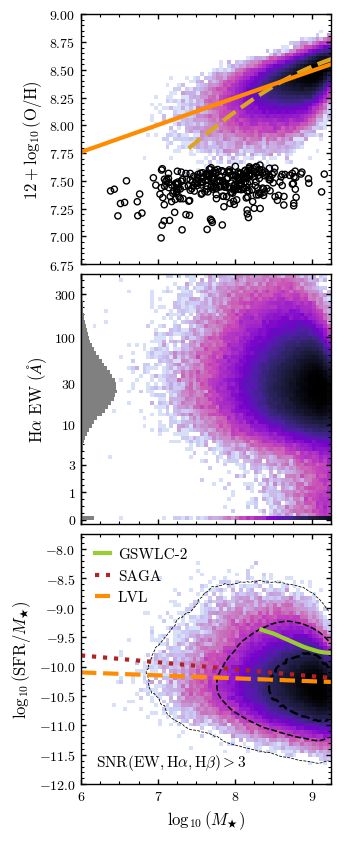

In [32]:

fig,ax = make_subplots(ncol=1,nrow=3,plot_size=2.5,return_fig=True,
                      col_spacing=[MARGIN_PAD]*2,
                      row_spacing=[MARGIN_PAD, MARGIN_SHARED, MARGIN_SHARED, MARGIN_PAD])


hist_nbins = 65
cont_nbins = 100

######

ax[0].hist2d( main_sfr["LOG_MSTAR_M24"][no_elg_mask], fiber_ssfr[no_elg_mask], 
            range=( (6,9.25), (-12,-7.75) ), 
          norm=LogNorm(),bins=hist_nbins, cmap = cmap, rasterized=True )

plot_2d_dist(main_sfr["LOG_MSTAR_M24"][no_elg_mask], fiber_ssfr[no_elg_mask], cont_nbins, cont_nbins, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0, 0.68,0.95,0.997],ax=ax[0], bounds= np.array([ 6,9.25,-12,-7.75]),
            cmap = make_cmap("darkblue"), color = "k", filled=False, label = None,cmap_alpha=1, lw_scale=.75,
            alternating_contours=False)

##put some other relations on top!
mstar_grid = np.linspace(6,11,50)

# Salim et al. 2018 — digitized from figure

#this is from SED fitting
logM_salim18 = np.array([
    8.344525547445254, 8.395591123618562, 8.445378594670654, 8.495166065722744,
    8.544953536774836, 8.594741007826928, 8.64452847887902, 8.694315949931111,
    8.744103420983203, 8.793890892035293, 8.843678363087385, 8.893465834139477,
    8.943253305191568, 8.99304077624366, 9.042828247295752, 9.092615718347844,
    9.142403189399936, 9.192190660452027, 9.24197813150412, 9.29176560255621,
    9.341553073608301, 9.391340544660393, 9.441128015712485, 9.490915486764576,
    9.540702957816668, 9.590490428868758, 9.64027789992085, 9.690065370972942,
    9.739852842025034, 9.789640313077125, 9.839427784129217, 9.889215255181309,
    9.9390027262334, 9.988790197285493, 10.038577668337584, 10.088365139389674,
    10.138152610441766, 10.187940081493858, 10.23772755254595, 10.287515023598042,
    10.337302494650134, 10.387089965702224, 10.436877436754315, 10.486664907806407,
    10.536452378858499, 10.58623984991059, 10.636027320962683, 10.685814792014774,
    10.735602263066866, 10.785389734118958, 10.83517720517105, 10.88496467622314,
    10.934752147275232, 10.984539618327323, 11.034327089379415, 11.084114560431507,
    11.133902031483597, 11.183689502535689, 11.23347697358778, 11.283264444639872,
    11.333051915691964, 11.382839386744056, 11.432626857796148, 11.48241432884824,
])

logsSFR_salim18 = np.array([
    -9.371769383697814, -9.396945091045549, -9.41690746357924, -9.436169401988941,
    -9.463136115762525, -9.492204131908077, -9.520571713929638, -9.5489392959512,
    -9.577657095034755, -9.606725111180307, -9.635442910263864, -9.66416070934742,
    -9.686574601315074, -9.706536973848765, -9.727199780506446, -9.74576128479216,
    -9.756968230775986, -9.763622354953883, -9.77027647913178, -9.779031905681645,
    -9.791989936975446, -9.801095580587305, -9.808099921827196, -9.818606433687034,
    -9.82666142611291, -9.831914682042829, -9.841370542716682, -9.85642987638245,
    -9.869037690614256, -9.869738124738245, -9.873590512420185, -9.879544202474094,
    -9.893903102015871, -9.912114389239589, -9.930325676463308, -9.948536963687026,
    -9.966748250910745, -9.984609321072469, -10.003170825358183, -10.020681678457912,
    -10.037492097433653, -10.053602082285403, -10.069361850075161, -10.085471834926912,
    -10.100531168592678, -10.114539851072463, -10.12889875061424, -10.142907433094024,
    -10.16251958856572, -10.185633914657364, -10.206997155439034, -10.229761264468682,
    -10.251124505250353, -10.272137528970028, -10.293500769751697, -10.314513793471374,
    -10.338328553687004, -10.363193965088621, -10.388059376490236, -10.412924787891853,
    -10.438840850479451, -10.465457347191041, -10.491723626840635, -10.517639689428234,
])

#this is from SALIM 2018!
ax[0].plot( logM_salim18, logsSFR_salim18,lw=3,ls="-",color="yellowgreen", label = "GSWLC-2" )

##This is from SAGA IV!
# -0.20164403469730652 - 10.09036823569727 * ( (-0.20164403469730652 - ( -3.8512359160889975) ) / ( 10.09036823569727  -  5.953858031699896 ) )
ax[0].plot(mstar_grid, 0.8822*mstar_grid - 9.1040 - mstar_grid, color="firebrick",ls="dotted",lw=3, label = "SAGA")

#LVL SEDs this is from the LVL FUV SFR, they assume kroupa imf
log_SFR = 0.95*mstar_grid - 9.8
ax[0].plot( mstar_grid, log_SFR - mstar_grid,ls="--",color="darkorange", lw=3, label = "LVL" )

#########################################

ax[0].legend(ncol=1,loc="upper left",
            handlelength=1,handletextpad=0.5, columnspacing=0.8)

ax[0].set_xlim([6,9.25])
ax[0].set_ylim([-12,-7.75])
ax[0].set_xlabel(r"$\log_{10}(M_{\bigstar})$")
ax[0].set_ylabel(r"$\log_{10}(\mathrm{SFR} / M_{\bigstar} )$")

ax[0].text(6.2,-11.7,
           r"$\mathrm{SNR}(\mathrm{EW}, \mathrm{H}\alpha, \mathrm{H}\beta) > 3$")


###############
###############
###############
###############

ax[1].hist2d( main_sfr["LOG_MSTAR_M24"][no_elg_mask], np.log10(fastspec_sfr["HALPHA_EW"][no_elg_mask]+1), 
            range=( (6,9.25), (-0.05,np.log10(500)) ), 
          norm=LogNorm(),bins=hist_nbins, cmap = cmap, rasterized=True )

from matplotlib.ticker import FuncFormatter

ax[1].set_ylim([-0.05,np.log10(500)])

# Choose physical EW values you want shown
ew_ticks = [0, 1, 3, 10, 30, 100, 300]
ax[1].set_yticks([np.log10(v + 1) for v in ew_ticks])
ax[1].set_yticklabels([str(v) for v in ew_ticks])

ax[1].set_ylabel(r"H$\alpha$ EW ($\AA$)")

#--- 

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create an inset on the left side of ax[1], inside the panel
ax_marg = inset_axes(
    ax[1],
    width="15%",        # horizontal extent — tweak to taste (10–20%)
    height="100%",      # full vertical extent to match the y-axis
    loc="lower left",
    borderpad=0,
)

# Compute the histogram in the same y-coordinate as the main panel: log10(EW+1)
y_vals = np.log10(fastspec_sfr["HALPHA_EW"][no_elg_mask] + 1)
y_vals = y_vals[(y_vals >= -0.05) & (y_vals <= np.log10(500))]   # match panel range

ax_marg.hist(
    y_vals,
    bins=hist_nbins,
    range=(-0.05, np.log10(500)),
    orientation="horizontal",
    color="grey",
    edgecolor="none",
)

# Match y-limits to the main panel exactly
ax_marg.set_ylim(ax[1].get_ylim())

# Strip ticks/labels — the main panel already shows them
ax_marg.set_yticks([])
ax_marg.set_xticks([])

# Optional: make the background transparent so the 2D hist shows through
ax_marg.patch.set_alpha(0.0)

# Optional: thin or remove spines for a cleaner look
for s in ["top", "right", "bottom"]:
    ax_marg.spines[s].set_visible(False)

    


###############
###############
###############
###############

ax[2].hist2d(main_sfr["LOG_MSTAR_M24"][no_elg_mask],  fastspec_sfr["Z_GAS_R23_N2"][no_elg_mask], range= ( (6,9.25), (6.75,9) ),
            norm=LogNorm(),bins=hist_nbins, cmap = cmap, rasterized=True)

ax[2].set_ylim([6.75,9])

ax[2].set_ylabel(r"$12 + \log_{10}(\mathrm{O}/\mathrm{H})$")

#mzr model from brett andrews et al. see Equation 5 and table 4
mstar_grid = np.linspace(7.4,10.5,100)
ax[2].plot(mstar_grid, 8.798 - np.log10( 1 + (10**8.901 / 10**mstar_grid)**0.640 ), color="goldenrod",lw=3,ls="--" ) 

##add scholte relation
def scholte24_rel(mstar):
    '''
    This is data from the table 1 in scholte et al. paper
    '''
    Z0=8.854
    gamma= 0.2439
    beta = 1.20
    m0 = 10**(10.49)
    return Z0 - (gamma/beta)*np.log10( 1 + (mstar/m0)**(-beta) )

mstar_grid = np.linspace(6,10.5,100)
ax[2].plot(mstar_grid, scholte24_rel(10**mstar_grid), color="darkorange",lw=3,ls="-" ) 

## add direct metallicities from the Sui et al sample?
sui26_tab = Table.read("/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/table1.fits")

# Filter main_sfr to only galaxies that appear in sui26_tab
mask = np.isin(main_sfr["TARGETID"].data, sui26_tab["TARGETID"].data)
main_zpoor_tab = main_sfr[mask]

# Now align the two tables by TARGETID so the rows correspond
# Build an index mapping: for each row in main_zpoor_tab, find its row in sui26_tab
sort_idx = np.argsort(sui26_tab["TARGETID"].data)
matched_idx = sort_idx[np.searchsorted(
    sui26_tab["TARGETID"].data[sort_idx],
    main_zpoor_tab["TARGETID"].data
)]

logM = main_zpoor_tab["LOG_MSTAR_M24"]
o_abund = sui26_tab["O_ABUNDANCE"][matched_idx]

len()

ax[2].scatter(logM, o_abund,
              s=20, marker="o",
              facecolor="none", edgecolor="k", linewidths=1.0,
              zorder=5, label="DESI XMPGs, Sui+26")

## add solar, 50% solar and 5% solar or something?

for i in range(1,3):
    ax[i].set_xticklabels([])

from matplotlib.ticker import MultipleLocator

for a in ax:
    a.xaxis.set_minor_locator(MultipleLocator(0.25))

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_ssfr.pdf")

plt.show()

In [30]:
sui26_tab = Table.read("/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/table1.fits")
print(len(sui26_tab))
sui26_tab = sui26_tab[sui26_tab["Z"].data < 0.5]
print(len(sui26_tab))

#so some objects in this catalog are higher redshift and masisive, so will not appear in our sample?

662
549


In [225]:
len(main), len(main_sfr), len(sui26_tab)

(461543, 397376, 549)

In [226]:
print( len(main_sfr[ np.isin( main_sfr["TARGETID"].data,  sui26_tab["TARGETID"].data ) ]) )

#it seems like there are objects that are not at all?? What is up with that ... check those ...
print( len(main[ np.isin( main["TARGETID"].data,  sui26_tab["TARGETID"].data ) ]) )


289
368


In [230]:
main_sfr_zpoor = main_sfr[ np.isin( main_sfr["TARGETID"].data,  sui26_tab["TARGETID"].data ) ]

main_all_zpoor = main[ np.isin( main["TARGETID"].data,  sui26_tab["TARGETID"].data ) ]


In [231]:
len(main_all_zpoor), len(main_sfr_zpoor)

(368, 289)

In [249]:
main_all_zpoor[ ~np.isin( main_all_zpoor["TARGETID"].data, main_sfr_zpoor["TARGETID"].data  ) ]["TARGETID","Z","RA","DEC","LOG_MSTAR_M24", "DWARF_MASKBIT", "MSTAR_MASKBIT"]


TARGETID,Z,RA,DEC,LOG_MSTAR_M24,DWARF_MASKBIT,MSTAR_MASKBIT
int64,float64,float64,float64,float64,int32,int32
39627732866306291,0.09138601348886496,148.94890550240046,-2.315205319012415,9.06037425994873,131072,2
39628451342195230,0.012039286270632476,335.01469386684914,28.40621562164472,7.2493438720703125,0,1
39632982134233389,0.06930994037754024,273.7828952022775,34.98802819572942,8.869072914123535,32768,0
39633035208951619,0.03762492606129128,235.9671688133769,37.82812707848545,8.260539054870605,32768,0
39627712884641698,0.10126273910631944,37.8940389679761,-3.0712111256060344,8.855597496032715,131072,3
39628517616387250,0.057144692381106976,217.01687419626026,31.873732950469808,7.92655086517334,0,4
2706466251210752,0.024915389123959544,348.4598721838494,11.5268884819054,7.567155838012695,32768,0
39627392272047091,0.4836539604822586,57.785884492381854,-16.375324825844967,8.79405689239502,131072,2
39627688779974855,0.44839685287326075,39.127704854861896,-3.9866378234879143,8.177330017089844,131072,2


In [248]:
2**17, 2**15

(131072, 32768)

In [207]:
clean_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v5.fits")
shred_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_shreds_catalog_v5.fits")
sga_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_desi_SGA_matched_dwarfs_REPROCESS_V2.fits")
other_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/hidden_dwarf_candidates_qso_mws_scnd.fits")

In [208]:
print( len(clean_cat[ np.isin( clean_cat["TARGETID"].data,  sui26_tab["TARGETID"].data ) ]) )
print( len(shred_cat[ np.isin( shred_cat["TARGETID"].data,  sui26_tab["TARGETID"].data ) ]) )
print( len(sga_cat[ np.isin( sga_cat["TARGETID"].data,  sui26_tab["TARGETID"].data ) ]) )
print( len(other_cat[ np.isin( other_cat["TARGETID"].data,  sui26_tab["TARGETID"].data ) ]) )

188
89
5
224


In [213]:
## need to inspect these!!
188 + 89 + 5 + 224

506

In [241]:
main[main["TARGETID"]==39628451342195230]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,bytes10,int64
39628451342195230,main,bright,13457,0.012039286270632476,24004.691210240126,0,0.010906309570759776,335.01469386684914,28.40621562164472,335.01469386684914,28.40621562164472,DESI J335.0146+28.4062,48.72683334350586,7.2493438720703125,0.0,19.09832000732422,19.073904037475586,19.37006950378418,19.09832000732422,19.073904037475586,19.37006950378418,BGS_BRIGHT,0,1,TRACTOR_OG,False,1.9196959733963013,0.5804636478424072 .. -37.451236724853516,False,[39628451342195230],39628451342195230,True,V_CMB,39628451342195230


In [243]:
main[main["TARGETID"]==39627732866306291]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,bytes10,int64
39627732866306291,main,bright,27189,0.09138601348886496,40858.639852523804,0,0.09265672216618781,148.94890550240046,-2.315205319012415,148.94890550240046,-2.315205319012415,DESI J148.9489-02.3152,438.73101806640625,9.06037425994873,0.01773439533988685,19.092273712158203,19.360782623291016,19.46051597595215,19.092273712158203,19.360782623291016,19.46051597595215,BGS_BRIGHT,131072,2,TRACTOR_OG,False,1.334453821182251,0.3371814489364624 .. 33.842620849609375,False,[39627732866306291],39627732866306291,True,V_CMB,39627732866306291


In [245]:
fastspec[fastspec["TARGETID"]==39627688779974855]

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,LOGMSTAR_FASTSPEC,MAG_G_DECAM_MODEL_NOEMI,MAG_R_DECAM_MODEL_NOEMI,MAG_G_DECAM_MODEL_WEMI,MAG_R_DECAM_MODEL_WEMI,MAG_G_BASS_MODEL_WEMI,MAG_R_BASS_MODEL_WEMI,MAG_G_SDSS_MODEL_NOEMI,MAG_R_SDSS_MODEL_NOEMI,MAG_G_SDSS_Z0_MODEL_NOEMI,MAG_R_SDSS_Z0_MODEL_NOEMI,DELTA_MAG_G_BASS2DECAM,DELTA_MAG_R_BASS2DECAM,DELTA_MAG_G_NEB,DELTA_MAG_R_NEB,DELTA_MAG_G_DECAM2SDSS,DELTA_MAG_R_DECAM2SDSS,DELTA_MAG_G_KCORR,DELTA_MAG_R_KCORR,MAG_G_FIBER_NOEMI,MAG_R_FIBER_NOEMI,MAG_G_FIBER_NOEMI_ERR,MAG_R_FIBER_NOEMI_ERR,LOG_SFR_HALPHA,LOG_SFR_HALPHA_ERR,LOG_MSTAR_24_FIBER,LOG_HALPHA_SFR_FIBER,Z_GAS_R23_N2
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64
39627688779974855,39.127704854861896,-3.9866378234879143,0.3829524,0.3508562,0.2386294,1.5554489,1.5276262,1.5554489,1.5717014,6.0932603,2.0421114,9.73922,1.9292163,4.420582,1.6641904,0.48352462,4.2473354,23.549398,1.6593206,41.300034,1.1847252,124.119835,0.40140802,2.2664192,7.3798013,0.42597884,2.0265036,63.98863,0.53200704,0.0,0.0,1.2490487,1.4763342,2.0074954,2.0164251,0.03209178,2.6104944,0.0,0.0,0.0,0.0,71.24712,0.016854994,350.99948,3.5717767e-05,1.0090711,0.66357833,10.732007,1.0525361,125.0,0.0,7.451208,23.561234479490057,23.26249731020968,23.46964392060478,22.957172986290175,23.482185329942517,22.947828925992823,23.565003672143035,23.229173437924025,23.715957721774306,24.053768487305195,-0.0,0.0,0.0915905588852759,0.3053243239195069,0.0037691926529781483,-0.033323872285656364,0.15095404963127024,0.8245950493811698,23.615683384682647,23.511780699579266,0.060484278251498276,0.08742824139186661,--,--,7.679813,--,--


In [246]:
### is the increased hiredshift offset because of sky subtraction residuals??
## what happens if I just k correct the best fit stellar pop template??
## maybe that is causing the issue??

## the higher the redshift, the rest-frame r band gets pushed more and more into the sky residuals part ... 
## so that is part of the issue??

## that could potentially help some of the weird trends we were seeing in the data

## this may explain the large magnitude in k correction in r band? 0.8245950493811698

## and these delta mag k corrections we add ... 


In [ ]:
## TODO: investigate why the above (for 39628451342195230) as Mg < -18.5 mask turned on?? somethign seems off...

In [198]:
## just in general need to know why their are not that many < 7 objects in these plots?? becauase based on
## the histogram their should be 100s? maybe they do not make the cuts? but they should exist in ew plot? unless they are all far of?

In [76]:
fspec = Table.read("/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/temp_cats/shreds_SPEC_DERIVED_hdu.fits")
main = Table.read("/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/temp_cats/shreds_MAIN_hdu.fits")


In [105]:
import h5py
import numpy as np

file_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5"

with h5py.File(file_path, "r") as f:
    # List all datasets in the file
    print("Datasets in file:", list(f.keys()))
    
    # Read each dataset into memory
    targetids = f["TARGETID"][:]     # shape (N_spectra,)
    zreds     = f["Z"][:]            # shape (N_spectra,)
    wave      = f["WAVE"][:]         # shape (N_wave,) -- same for all spectra
    flux      = f["FLUX"][:]         # shape (N_spectra, N_wave)
    flux_ivar = f["FLUX_IVAR"][:]    # shape (N_spectra, N_wave)
    
# Example: access the first spectrum
first_flux = flux[0, :]
first_z    = zreds[0]
first_targetid = targetids[0]

print("First spectrum TARGETID:", first_targetid)
print("First spectrum redshift:", first_z)
print("Flux array shape:", first_flux.shape)


Datasets in file: ['FLUX', 'FLUX_IVAR', 'TARGETID', 'WAVE', 'Z']
First spectrum TARGETID: 39627066986994125
First spectrum redshift: 0.032918606
Flux array shape: (7781,)


In [109]:
targetids[300000]

39628452176859651

(3700.0, 9800.0)

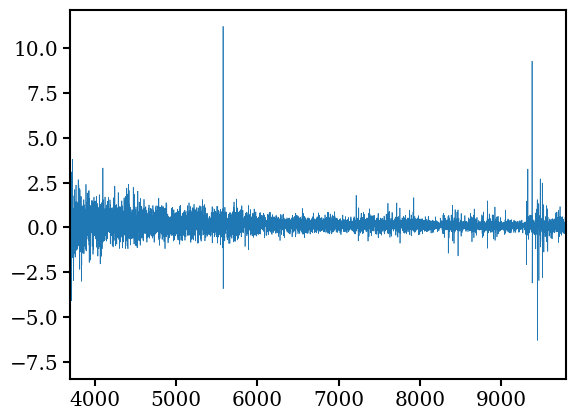

In [107]:
plt.plot(wave, flux[300000],lw=0.5)
plt.xlim([3700,9800])

In [82]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main = Table.read(filename, hdu="MAIN")

In [91]:
350000/350

1000.0

In [ ]:
Table.read("/pscratch/sd/v/virajvm/redo_photometry_plots/all_good/north/sweep-160p030-170p035/1697p327/LOWZ_tgid_2275928403083273/source_cat_all_main_segment.fits")



## Searching for broad components in emfit catalog

In [172]:
import sys
import os

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))


In [163]:
emfit_cat = Table.read("/global/cfs/cdirs/desi/public/dr1/vac/dr1/emfit/v2.3/emfit-dr1-v2.3.fits")

In [164]:
emfit_cat = emfit_cat["TARGETID","Z","HA_N_SIGMA","HA_N_SIGMA_ERR", "HA_N_SIGMA_FLAG", "HA_OUT_SIGMA", "HA_OUT_SIGMA_ERR", "HA_OUT_SIGMA_FLAG", "HA_B_SIGMA", "HA_B_SIGMA_ERR","HA_B_SIGMA_FLAG"]



In [165]:
mask = (emfit_cat["HA_OUT_SIGMA_FLAG"] == 0) | (emfit_cat["HA_N_SIGMA_FLAG"] == 0)  | (emfit_cat["HA_B_SIGMA_FLAG"] == 0) 

In [167]:
emfit_cat_v2 = emfit_cat[mask]

In [169]:
emfit_cat_broad = emfit_cat_v2[emfit_cat_v2["HA_B_SIGMA"] > 0]

In [176]:
main_tgids = main["TARGETID"].data
broad_tgids = emfit_cat_broad["TARGETID"].data

In [177]:
len(main_tgids), len(broad_tgids)

(451538, 180581)

In [181]:
main_broad_det = main[np.isin(main_tgids, broad_tgids)]

In [186]:
emfit_cat_broad[emfit_cat_broad["TARGETID"]==39627334671665216]

TARGETID,Z,HA_N_SIGMA,HA_N_SIGMA_ERR,HA_N_SIGMA_FLAG,HA_OUT_SIGMA,HA_OUT_SIGMA_ERR,HA_OUT_SIGMA_FLAG,HA_B_SIGMA,HA_B_SIGMA_ERR,HA_B_SIGMA_FLAG
,,km / s,km / s,,km / s,km / s,,km / s,km / s,
int64,float64,float64,float64,int64,float64,float64,int64,float64,float64,int64
39627334671665216,0.03948277090766776,21.592000969012176,0.6303051558768068,0,0.0,0.0,-1,134.96768488612636,21.47711022488681,0


In [190]:
main_broad_26A = main_broad_det[(main_broad_det["Z"] < 0.01) & (main_broad_det["DEC"] < 10) & ( (main_broad_det["RA"] > 80) | (main_broad_det["RA"] < 40) ) ]  

In [201]:
main_broad_26A

for i in range(len(main_broad_26A)):
    print(f'TGID={main_broad_26A["TARGETID"].data[i]},RA,DEC={main_broad_26A["RA"].data[i]:.4f},{main_broad_26A["DEC"].data[i]:.4f},LogM={main_broad_26A["LOG_MSTAR_SAGA"].data[i]:.1f}, Z={main_broad_26A["Z"].data[i]:.3f}, MASKBIT={main_broad_26A["DWARF_MASKBIT"].data[i]:d} ')
    
    temp = emfit_cat_broad[emfit_cat_broad["TARGETID"] == main_broad_26A["TARGETID"].data[i]]
    print(f'HA_B_SIGMA = {temp["HA_B_SIGMA"].data[0]:.1f} +/- {temp["HA_B_SIGMA_ERR"].data[0]:.1f}')
    print("---")

TGID=39627679858691316,RA,DEC=226.4978,-4.4615,LogM=8.5, Z=0.007, MASKBIT=0 
HA_B_SIGMA = 136.5 +/- 4.8
---
TGID=39627721143225249,RA,DEC=170.1505,-2.7436,LogM=8.2, Z=0.008, MASKBIT=0 
HA_B_SIGMA = 163.6 +/- 16.8
---
TGID=39627742769053897,RA,DEC=19.0052,-1.7664,LogM=6.4, Z=0.006, MASKBIT=0 
HA_B_SIGMA = 170.4 +/- 31.4
---
TGID=39627788411473940,RA,DEC=219.6940,-0.0272,LogM=7.6, Z=0.006, MASKBIT=0 
HA_B_SIGMA = 260.9 +/- 6.6
---
TGID=39627806086268813,RA,DEC=193.1109,0.6951,LogM=7.0, Z=0.010, MASKBIT=0 
HA_B_SIGMA = 567.0 +/- 56.3
---
TGID=39627995329070768,RA,DEC=350.2326,8.3853,LogM=8.1, Z=0.009, MASKBIT=0 
HA_B_SIGMA = 158.9 +/- 2.1
---
TGID=39636701349417815,RA,DEC=348.6967,4.6386,LogM=8.8, Z=0.010, MASKBIT=0 
HA_B_SIGMA = 649.8 +/- 12.8
---
TGID=39627899812187631,RA,DEC=23.1668,4.6415,LogM=8.0, Z=0.007, MASKBIT=0 
HA_B_SIGMA = 191.6 +/- 16.7
---
TGID=39627905885538609,RA,DEC=26.1739,4.8943,LogM=8.1, Z=0.005, MASKBIT=0 
HA_B_SIGMA = 214.9 +/- 8.9
---
TGID=39627595087614545,RA,DEC=1